In [2]:
import os
import skrf as rf
import numpy as np
from scipy.signal import savgol_filter


def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_and_smooth_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Returns two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_original"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list

def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB


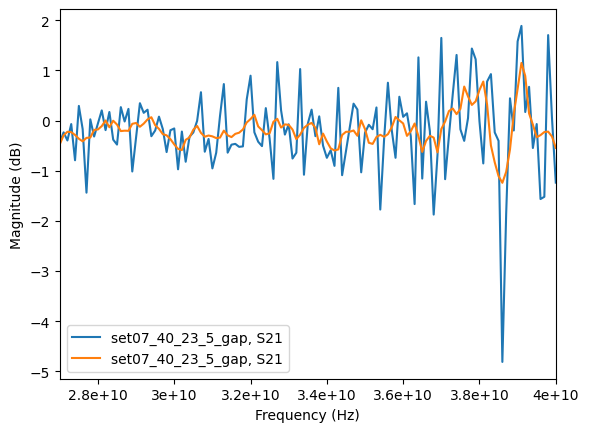

In [3]:
set_07_original, set_07_smoothed = load_and_smooth_directory(r'meas data\sample1_quarter\set07', window=11, poly=3)
# plt.figure()
# plt.title('S11 Magnitude (dB)')
# for ntwk in set_07_smoothed:
#     ntwk.plot_s_db(m=1, n=0, show_legend=False)

# # plt.legend()
# plt.show()
set_07_original[9].plot_s_db(m=1, n=0)
set_07_smoothed[9].plot_s_db(m=1, n=0)

In [4]:
results = []
for ntwk in set07_smoothed:
    results.append((ntwk.name, avg_return_loss(ntwk)))

results_sorted = sorted(results, key=lambda x: x[1])
print(results_sorted)

[('set07_40_21_5_gap', np.float64(-24.848049934579286)), ('set07_40_23_5_gap', np.float64(-23.771734816525093)), ('set07_40_25_5_gap', np.float64(-22.777033212647485)), ('set07_40_22_5_gap', np.float64(-21.30352898198248)), ('set07_40_14_5_gap', np.float64(-18.086956346528712)), ('set07_40_20_5_gap', np.float64(-17.63321136772592)), ('set07_40_18_5_gap', np.float64(-17.212280339777426)), ('set04_40_22_5_gap_re', np.float64(-17.151816024490092)), ('set07_40_16_5_gap', np.float64(-16.804331611541)), ('set07_40_17_5_gap', np.float64(-16.793569241530577)), ('set07_40_19_5_gap', np.float64(-16.553456186396907))]


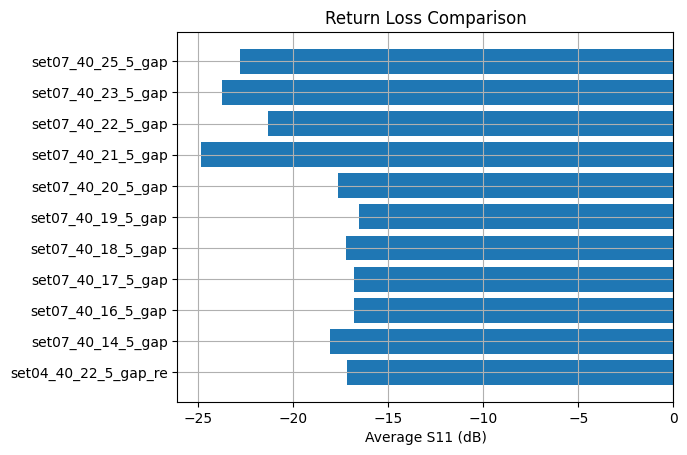

In [111]:
names = []
values = []

for ntwk in set07_smoothed:
    names.append(ntwk.name)
    values.append(avg_return_loss(ntwk))

plt.figure()
plt.barh(names, values)
plt.grid()
plt.xlabel("Average S11 (dB)")
plt.title("Return Loss Comparison")
plt.show()

Text(0.5, 1.0, 'Return Loss Comparison')

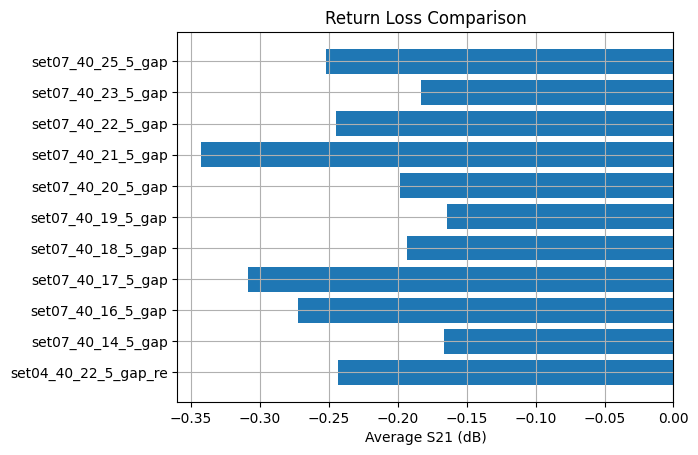

In [109]:
names = []
values = []

for ntwk in set07_smoothed:
    names.append(ntwk.name)
    values.append(avg_transmit_loss(ntwk))
plt.figure()
plt.grid()
plt.barh(names, values)
plt.xlabel("Average S21 (dB)")
plt.title("Return Loss Comparison")

In [5]:
set_07_smoothed

[2-Port Network: 'set04_40_22_5_gap_re',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_14_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_16_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_17_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_18_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_19_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_20_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_21_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_22_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set07_40_23_5_gap',  27000000000.0-40000000000.0 Hz, 131 pts,